# Urban Infrastructure & Public Safety Modeling

## Purpose
This notebook builds and evaluates models to study how urban infrastructure relates to:
1) violent crime (regression) and  
2) pedestrian-vehicle accident (PVA) hotspots (classification)  
across Charlotte census tracts.

Workflow:
- Load and merge public datasets (Charlotte Open Data, NCDOT, U.S. Census)
- Spatial joins + tract-level feature engineering
- Model training + validation (cross-validation, tuning)
- Interpretation of key predictors

In [ ]:
!pip install libpysal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 20.2 MB/s eta 0:00:00


In [ ]:
!pip install ISLP

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.4 MB/s eta 0:00:00
  

In [ ]:
from itertools import combinations

from shapely.geometry import LineString
import numpy as np
import seaborn as sns
import pandas as pd
import geopandas as gpd
import json
import libpysal
from libpysal.weights import lag_spatial

# from ISLP.models import sklearn_sm, ModelSpec as MS

from urllib.request import urlopen
from google.colab import drive

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_validate, LeaveOneOut

import statsmodels.api as sm

drive.mount('/content/drive')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

Mounted at /content/drive


In [ ]:
gini_index_df = pd.read_csv("/content/drive/MyDrive/DTSC2302Project2/ACSDT5Y2023.B19083-2025-04-29T193604.csv")
# block_groups_gdf = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/tl_2024_37_bg.shp")
# tract_poverty_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/ACSST5Y2021.S1701-2025-04-25T195243.csv")
# tracts_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/tl_2024_37_tract.shp")
# tract_populations = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/DECENNIALDHC2020.P1-2025-04-25T203255.csv")
# council_districts_gdf = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Council_Districts.geojson")
# incidents_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/CMPD_Incidents.geojson")
# crashes_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Crashes.geojson")
# daycare_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Day_Care.geojson")
# financial_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Financial_Institutions_(points).geojson")
# grocery_store_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Grocery_Stores_(points).geojson")
# libraries_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Libraries.geojson")
# parks_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Parks.geojson")
# worship_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Places_of_Worship.geojson")
# post_office_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Post_Office (1).geojson")
# schools_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Pharmacies_(points).geojson")
# shopping_centers_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Existing_Shopping_Centers.geojson")
# medical_fac_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Medical_Facilities_(points).geojson")
# traffic_signals_geo = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Traffic_Signals.geojson")
# bus_stops_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Bus_Stops_With_Frequency_HLT.geojson")
# speed_bumps_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Speed_Humps.geojson")
# streets_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Streets.geojson")
# sidewalk_df = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/Sidewalk_Inventory (1).geojson")
# traffic_counts = gpd.read_file("/content/drive/MyDrive/DTSC2302Project2/NCDOT_AADT_Stations.shp")

In [ ]:
# geo dataframe giving poverty percentage for each census tract
tract_poverty_df = tract_poverty_df.T[0].iloc[1:].reset_index().rename(columns={"index":"TractID", 0:"pct_poverty"})
tract_poverty_df["TractID"] = tract_poverty_df["TractID"].str.split(",").str[0] # remove county and state metadata
tract_poverty_df["pct_poverty"] = tract_poverty_df["pct_poverty"].apply(
    lambda x: float(x.replace("%",""))/100 if x!="-" else np.nan # convert format 24.5% to  format 0.245
)

# get populations for each census tract
tract_populations = tract_populations.T.iloc[1:].reset_index().rename(columns={"index":"TractID", 0:"Population"})
tract_populations["TractID"] = tract_populations["TractID"].str.split(";").str[0] # remove county and state metadata
tract_populations["Population"] = tract_populations["Population"].apply(lambda x: x.replace(",", "")).astype(int)

# merge poverty information with population information for census tracts
tract_info = pd.merge(tract_poverty_df, tract_populations, on="TractID", how="inner")
tracts_df.rename(columns={"NAMELSAD":"TractID"}, inplace=True)

# merge dataframe containing the boundaries of each census tract
tracts_df = pd.merge(tracts_df, tract_info, on="TractID", how="inner")
tracts_df.dropna(subset=["pct_poverty"],inplace=True)
tracts_df = tracts_df[["TractID", "Population", "pct_poverty", "geometry"]]

tracts_df.crs = "EPSG:4269"
tracts_df = tracts_df.to_crs(council_districts_gdf.crs) # ensure using same crs
# compute the center of each census tract
tracts_df["centroid"] = tracts_df.geometry.representative_point()
centroids_gdf = tracts_df.set_geometry("centroid")
# see which census tract centers lie within one of the city council polygons, essentially checking if
# a block group is in charlotte city limits or not
centroids_within_city = gpd.sjoin(centroids_gdf, council_districts_gdf, how="inner", predicate="within")
tracts_df = tracts_df.loc[tracts_df.index.isin(centroids_within_city.index)]
tracts_df.drop(columns=["centroid"], inplace=True)

In [ ]:
# find population density of each tract
tracts_df = tracts_df.to_crs("EPSG:32617") # convert to projected crs to accurately calculate area in meters
tracts_df["area"] = tracts_df.geometry.area / 10**6 # get area in square kilometers
tracts_df["population_density"] = tracts_df["Population"] / tracts_df["area"]
tracts_df = tracts_df.to_crs("EPSG:4269") # convert back to original crs
tracts_df = tracts_df.drop(columns=["area"])

In [ ]:
traffic_counts.crs = "EPSG:4269" # initialize a crs
traffic_counts = traffic_counts[traffic_counts["COUNTY"]=="MECKLENBURG"]
traffic_counts = traffic_counts.to_crs(tracts_df.crs) # ensure both datasets use same crs
traffic_counts = gpd.sjoin(traffic_counts, tracts_df, how="left", predicate="within")

def get_most_recent_traffic_count(row):
  i = 26 # column index of most recent traffic count year
  while pd.isna(row.iloc[i]): i -= 1 # go to previous year
  return row.iloc[i]

traffic_counts["daily_traffic"] = traffic_counts.apply(get_most_recent_traffic_count, axis=1).astype(int)
traffic_counts = traffic_counts[["TractID", "daily_traffic"]]
traffic_counts = traffic_counts.dropna(subset=["TractID"])
traffic_counts = traffic_counts.groupby('TractID').mean().reset_index() # average traffic counts by census tract

In [ ]:
crashes_df = crashes_df.to_crs(tracts_df.crs)
crashes_df = gpd.sjoin(crashes_df, tracts_df, how="left", predicate="within")
unwanted_crashes = ["Property Damage", "Non Serious Damage", "None", "Unknown"]

# filter out non serious crashes and old crash data to avoid look ahead bias
# crashes_df = crashes_df[(~crashes_df["CRSH_LEVL_DESC"].isin(unwanted_crashes)) \
#                         &(crashes_df["DATE_VAL_YEAR"].isin(["2023","2024","2025"]))]

crashes_df = crashes_df[(crashes_df["CRASH_TYPE"]=="Pedestrian") \
               &(crashes_df["DATE_VAL_YEAR"].isin(["2019","2020","2021","2022","2023","2024","2025"]))]

crashes_df = crashes_df.groupby("TractID").size().reset_index(name="num_crashes")

In [ ]:
violent_crimes = [
    'Aggravated Assault','Simple Assault',
    'Intimidation','Kidnapping',
    'Robbery','Forcible Rape',
    'Forcible Fondling','Forcible Sodomy',
    'Sexual Assault With Object','Murder',
    'Negligent Manslaughter','Justifiable Homicide',
    'Human Trafficking, Commercial Sex Acts',
    'Human Trafficking, Involuntary Servitude',
    'Burglary/B&E'
]

incidents_df = incidents_df[incidents_df["HIGHEST_NIBRS_DESCRIPTION"].isin(violent_crimes)]
incidents_df = incidents_df[incidents_df["YEAR"].isin(["2022","2023","2024"])]

# incidents_df = incidents_df.to_crs(zipcodes_gdf.crs)
# incidents_df = gpd.sjoin(incidents_df, zipcodes_gdf, how="left", predicate="within")
# incidents_df = incidents_df.groupby('Zip').size().reset_index(name='violent_crimes')


incidents_df = incidents_df.to_crs(tracts_df.crs)
incidents_df = gpd.sjoin(incidents_df, tracts_df, how="left", predicate="within")
incidents_df = incidents_df.groupby('TractID').size().reset_index(name='violent_crimes')

incidents_df = pd.merge(incidents_df, tracts_df, on="TractID", how="right")
incidents_df = incidents_df[["TractID", "violent_crimes", "Population", "geometry"]]

# divide by 3000 to get rate per 1000 people per year
#incidents_df["violent_crimes"] = incidents_df["violent_crimes"].div(incidents_df["Population"])*1000/3
incidents_df.fillna({"violent_crimes":0}, inplace=True) # fill unmatched census tracts with 0
incidents_df = incidents_df[["TractID", "violent_crimes"]]

In [ ]:
gini_index_df = gini_index_df.iloc[:, 1:gini_index_df.shape[1]:2] # skip over margin of error columns
gini_index_df = gini_index_df.T.reset_index().rename(columns={0:"gini_index", "index":"TractID"})
gini_index_df["TractID"] = gini_index_df["TractID"].str.split(";").str[0] # remove county and state metadata
gini_index_df = gini_index_df[gini_index_df["TractID"].isin(tracts_df["TractID"])]

In [ ]:
bus_stops_df = bus_stops_df.to_crs(tracts_df.crs)
bus_stops_df = gpd.sjoin(bus_stops_df, tracts_df, how="left", predicate="within")
bus_stops_df = bus_stops_df.groupby('TractID').size().reset_index(name='bus_stops')

In [ ]:
traffic_signals_geo["PED_BUTTONS"] = traffic_signals_geo["PED_BUTTONS"].replace({"Y": 1, "N": 0}) # make dummy var.
traffic_signals_geo = traffic_signals_geo[["geometry", "PED_BUTTONS", "INSTALLATION_DATE"]]

traffic_signals_geo = traffic_signals_geo.to_crs(tracts_df.crs)
traffic_lights_gdf = gpd.sjoin(traffic_signals_geo, tracts_df, how="left", predicate="within")
grouped_tf_lights_gdf = traffic_lights_gdf.groupby('TractID')

traffic_light_count = grouped_tf_lights_gdf.size().reset_index(name='traffic_lights')
crosswalk_pct = (
    grouped_tf_lights_gdf["PED_BUTTONS"]
    .apply(lambda x: (x == 1).mean()) # percentage of traffic lights w/ pedestrian buttons
    .reset_index(name="pct_tl_crosswalk")
)
traffic_light_df = traffic_light_count.merge(crosswalk_pct, on="TractID")

In [ ]:
post_office_df = post_office_df.to_crs(tracts_df.crs)
post_office_df = gpd.sjoin(post_office_df, tracts_df, how="left", predicate="within")
post_office_df = post_office_df.groupby('TractID').size().reset_index(name='post_offices')

In [ ]:
daycare_df = daycare_df.to_crs(tracts_df.crs)
# daycare_df.drop(columns=["TractID"], inplace=True)
daycare_df = gpd.sjoin(daycare_df, tracts_df, how="left", predicate="within")
daycare_df = daycare_df.groupby('TractID').size().reset_index(name='daycares')

# daycare_df = daycare_df.to_crs(tracts_df.crs)
# #daycare_df.drop(columns=["Zip"], inplace=True)
# daycare_df = gpd.sjoin(daycare_df, tracts_df, how="left", predicate="within")
# daycare_df = daycare_df.groupby('TractID').size().reset_index(name='daycares')

# daycare_df = pd.merge(daycare_df, tracts_df, on="TractID", how="right") # not all blocks have zip codes
# daycare_df = daycare_df[["TractID", "daycares", "Population", "geometry"]]
# daycare_df.loc[:, "daycares"] = daycare_df["daycares"]/daycare_df["Population"]*1000 # get zipcodes per 1000 people
# daycare_df.fillna({"daycares":0}, inplace=True) # fill unmatched block groups with 0

# daycare_df = gpd.GeoDataFrame(daycare_df, geometry="geometry")
# daycare_df = daycare_df.to_crs(epsg=3857) # use a projected coordinate system, this is the one used for google maps
# w = libpysal.weights.Queen.from_dataframe(daycare_df, use_index=False) # get neighbor matrix for block group
# w.transform = 'R' # normalizes distances

# daycare_df['neighbor_daycares'] = lag_spatial(w, daycare_df['daycares'])
# alpha = 0.5
# daycare_df['daycare_score'] = alpha * daycare_df['daycares'] \
#                             + (1 - alpha) * daycare_df['neighbor_daycares']
# daycare_df = daycare_df[["TractID", "daycare_score"]]

In [ ]:
financial_df = financial_df.to_crs(tracts_df.crs)
financial_df = gpd.sjoin(financial_df, tracts_df, how="left", predicate="within")
financial_df = financial_df.groupby('TractID').size().reset_index(name='financial_insts')

In [ ]:
shopping_centers_df = shopping_centers_df.to_crs(tracts_df.crs)
shopping_centers_df = gpd.sjoin(shopping_centers_df, tracts_df, how="left", predicate="within")
shopping_centers_df = shopping_centers_df.groupby('TractID').size().reset_index(name='shopping_centers')

In [ ]:
medical_fac_df = medical_fac_df.to_crs(tracts_df.crs)
medical_fac_df = gpd.sjoin(medical_fac_df, tracts_df, how="left", predicate="within")
medical_fac_df = medical_fac_df.groupby('TractID').size().reset_index(name='med_facilities')

In [ ]:
grocery_store_df = grocery_store_df.to_crs(tracts_df.crs)
grocery_store_df = gpd.sjoin(grocery_store_df, tracts_df, how="left", predicate="within")
grocery_store_df = grocery_store_df.groupby('TractID').size().reset_index(name='grocery_stores')

In [ ]:
parks_df = parks_df.to_crs(tracts_df.crs)
parks_df = gpd.sjoin(parks_df, tracts_df, how="left", predicate="within")
parks_df = parks_df.groupby('TractID').size().reset_index(name='parks')

In [ ]:
libraries_df = libraries_df.to_crs(tracts_df.crs)
libraries_df = gpd.sjoin(libraries_df, tracts_df, how="left", predicate="within")
libraries_df = libraries_df.groupby('TractID').size().reset_index(name='libraries')

In [ ]:
worship_df = worship_df.to_crs(tracts_df.crs)
worship_df = gpd.sjoin(worship_df, tracts_df, how="left", predicate="within")
worship_df = worship_df.groupby('TractID').size().reset_index(name='worship_centers')

# worship_df = worship_df.to_crs(tracts_df.crs)
# #daycare_df.drop(columns=["Zip"], inplace=True)
# worship_df = gpd.sjoin(worship_df, tracts_df, how="left", predicate="within")
# worship_df = worship_df.groupby('TractID').size().reset_index(name='worship_centers')

# worship_df = pd.merge(worship_df, tracts_df, on="TractID", how="right") # not all blocks have zip codes
# worship_df = worship_df[["TractID", "worship_centers", "Population", "geometry"]]
# worship_df.loc[:, "worship_centers"] = worship_df["worship_centers"]/worship_df["Population"]*1000 # get med facs per 1000 people
# worship_df.fillna({"worship_centers":0}, inplace=True) # fill unmatched block groups with 0

# worship_df = gpd.GeoDataFrame(worship_df, geometry="geometry")
# worship_df = worship_df.to_crs(epsg=3857) # use a projected coordinate system
# w = libpysal.weights.Queen.from_dataframe(worship_df, use_index=False) # get neighbor matrix for block group
# w.transform = 'R' # normalizes distances

# worship_df['neigbor_worship'] = lag_spatial(w, worship_df['worship_centers'])
# alpha = 0.6
# worship_df['worship_score'] = alpha * worship_df['worship_centers'] \
#                             + (1 - alpha) * worship_df['neigbor_worship']
# worship_df = worship_df[["TractID", "worship_score"]]

In [ ]:
schools_df = schools_df.to_crs(tracts_df.crs)
schools_df = gpd.sjoin(schools_df, tracts_df, how="left", predicate="within")
schools_df["Type"].replace({"Special": "High", "Charter":"Private"}, inplace=True)
schools_counts = (
    schools_df
    .groupby(["TractID", "Type"])
    .size()
    .reset_index(name="count")
)
schools_df = schools_counts.pivot_table(index="TractID", columns="Type", values="count", fill_value=0)
schools_df["TotalSchools"] = schools_df.sum(axis=1)
schools_df = schools_df.reset_index()

<ipython-input-33-a04c9ffe81c9>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  schools_df["Type"].replace({"Special": "High", "Charter":"Private"}, inplace=True)


In [ ]:
speed_bumps_df = speed_bumps_df.to_crs(tracts_df.crs)
speed_bumps_df = gpd.sjoin(speed_bumps_df, tracts_df, how="left", predicate="within")
speed_bumps_df = speed_bumps_df.groupby("TractID").size().reset_index(name="speed_bumps")

In [ ]:
# change coordinate systems to get more accurate length measurements
tracts_df = tracts_df.to_crs("EPSG:32617") # accurate projected crs encompassing all of charlotte
streets_df = streets_df.to_crs("EPSG:32617")
sidewalk_df = sidewalk_df.to_crs("EPSG:32617")
streets_df["SPEEDLIMIT"] = streets_df["SPEEDLIMIT"].astype(int)

tract_street_lengths = {}
tract_speedlimit_numerators = {}
tract_speedlimit_denominators = {}
for speed_limit, street_geom in zip(streets_df["SPEEDLIMIT"], streets_df["geometry"]):
  # get the indexes of zip codes that are intersected by this streeet
  matched_tract_idxs = list(tracts_df.sindex.intersection(street_geom.bounds))
  tracts = list(tracts_df.iloc[matched_tract_idxs]["TractID"])
  polygons = list(tracts_df.iloc[matched_tract_idxs]["geometry"])
  if len(tracts)==0: continue # street is not in any clt zip code
  # add the length of the intersection to each zip code that the street intersects
  for tract, polygon in zip(tracts, polygons):
    intersection = polygon.intersection(street_geom)
    if not intersection.is_empty and intersection.length > 0:
      tract_street_lengths[tract] = tract_street_lengths.get(tract, 0) \
                                      + intersection.length
      tract_speedlimit_numerators[tract] = tract_speedlimit_numerators.get(tract, 0) + speed_limit * intersection.length
      tract_speedlimit_denominators[tract] = tract_speedlimit_denominators.get(tract, 0) + intersection.length

tract_sidewalk_lengths = {}
for street_geom, has_sidewalk in zip(sidewalk_df["geometry"], sidewalk_df["SidewalkPresence"]):
  if has_sidewalk == "Sidewalk":
    matched_tract_idxs = list(tracts_df.sindex.intersection(street_geom.bounds))
    tracts = list(tracts_df.iloc[matched_tract_idxs]["TractID"])
    polygons = list(tracts_df.iloc[matched_tract_idxs]["geometry"])
    if len(tracts)==0: continue
    for tract, polygon in zip(tracts, polygons):
      intersection = polygon.intersection(street_geom)
      if not intersection.is_empty and intersection.length > 0:
        tract_sidewalk_lengths[tract] = tract_sidewalk_lengths.get(tract, 0) \
                                        + intersection.length

# change back to original coordinate systems:
tracts_df = tracts_df.to_crs("EPSG:4269")
streets_df = streets_df.to_crs("EPSG:4269")
sidewalk_df = sidewalk_df.to_crs("EPSG:4269")

sidewalk_df = pd.DataFrame.from_dict(tract_sidewalk_lengths, orient="index").reset_index()
sidewalk_df = sidewalk_df.rename(columns={"index":"TractID", 0:"tot_sidewalk_length"})
street_df = pd.DataFrame.from_dict(tract_street_lengths, orient="index").reset_index()
street_df = street_df.rename(columns={"index":"TractID", 0:"tot_street_length"})
speed_df = pd.DataFrame({
    "TractID": list(tract_speedlimit_numerators.keys()),
    "speed_numerator": list(tract_speedlimit_numerators.values()),
    "speed_denominator": list(tract_speedlimit_denominators.values())
})
speed_df["weighted_speed_limit"] = speed_df["speed_numerator"] / speed_df["speed_denominator"]
speed_df = speed_df[["TractID", "weighted_speed_limit"]]

sidewalks = pd.merge(sidewalk_df, street_df, on="TractID", how="inner")
sidewalks["sidewalk_pct"] = sidewalks["tot_sidewalk_length"] / sidewalks["tot_street_length"]
sidewalks = sidewalks.drop(columns=["tot_sidewalk_length", "tot_street_length"])

In [ ]:
dfs = [bus_stops_df, traffic_light_df, schools_df,
       crashes_df, speed_bumps_df, traffic_counts,
       sidewalks, sidewalk_df, speed_df]

full_crash_df = tracts_df.copy()
for df in dfs:
  # merge all datasets on tract id
  full_crash_df = pd.merge(full_crash_df, df, on="TractID", how="outer")

full_crash_df.drop(columns=["pct_poverty"], inplace=True)
full_crash_df = full_crash_df.fillna(0).set_index("TractID") # fill values for unmatched tract ids
full_crash_df = full_crash_df.drop(columns=["geometry", "Elementary", "High", "Middle", "Private", "Religious"])

# discretize the number of crashes to above median or below median
full_crash_df["high_crash_rate"] = full_crash_df.apply(
    lambda row: 1 if row["num_crashes"] >= full_crash_df["num_crashes"].median() else 0,
    axis=1
)

full_crash_df.to_csv("crash_data.csv")

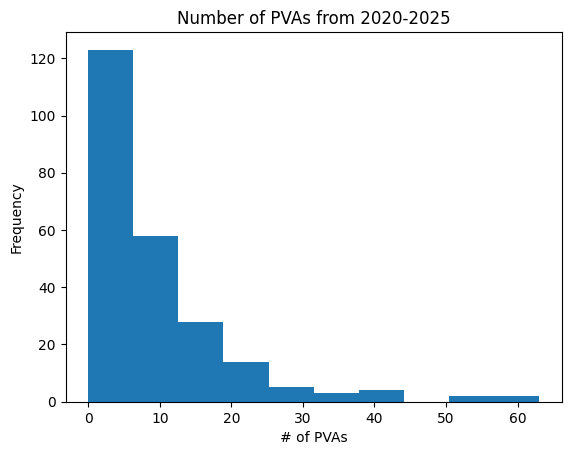

In [ ]:
full_crash_df["num_crashes"].plot(kind="hist", bins=10)
plt.title("Number of PVAs from 2020-2025")
plt.xlabel("# of PVAs")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# scaler = StandardScaler()
# scaled_features = pd.DataFrame(
#     scaler.fit_transform(full_crash_df.drop(columns=["num_crashes", "high_crash_rate"])),
#     columns=full_crash_df.drop(columns=["num_crashes", "high_crash_rate"]).columns,
#     index=full_crash_df.index
# )
# scaled_features = sm.add_constant(scaled_features)
# model = sm.Logit(full_crash_df["high_crash_rate"], scaled_features)
# model = model.fit()
# print(model.summary())

In [ ]:
# merging data
dfs = [
    schools_df, worship_df, libraries_df
    parks_df, grocery_store_df, financial_df, medical_fac_df,
    daycare_df, post_office_df, shopping_centers_df, incidents_df
]
full_crime_df = tracts_df.copy()
for df in dfs:
  full_crime_df = pd.merge(full_crime_df, df, on="TractID", how="outer")
full_crime_df = full_crime_df.fillna(0).set_index("TractID") # replace non-matched zip code values with 0

num_columns = [ # columns that need to be divided out by population
    "Elementary", "High", "Middle", "Private", "Religious",
    "TotalSchools", "worship_centers", "libraries", "parks", "daycare_score",
    "post_offices", "grocery_stores","shopping_centers", "financial_insts",
    "med_facilities", "violent_crimes"
]

# discretize crime rate to be 1 if zip code's violent crime is >= median else 0
full_crime_df["high_crime"] = full_crime_df.apply(
    lambda row: 1 if row["violent_crimes"] >= full_crime_df["violent_crimes"].median() else 0,
    axis=1
)

# full_crime_df = full_crime_df.drop(columns=["Population", "geometry"])
full_crime_df.to_csv("zip_code_crime.csv", index_label="TractID")

In [ ]:
def subset_and_cv(model, features, target, cv, scale_data, param_grid) -> tuple:
  """
  Evaluates all possible subsets of features and selects the best subset based on
  cross-validated accuracy.
  Returns:
  tuple:
      - highest_f1 (float): The highest cross-validated F1-score achieved.
      - best_subset (tuple): The subset of feAature names that yielded the highest F1-score.
      - scaler (StandardScaler or None): The fitted StandardScaler object if `scale_data` is True, otherwise None.
  """
  if scale_data:
    scaler = StandardScaler()
    scaled_features = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)
  else:
    scaler = None
    scaled_features = features
  feature_names = features.columns
  highest_acc = 0 # highest accuracy found
  best_subset = None
  # try all # of features
  for i in range(3, 6):
    for combination in combinations(feature_names, i):
      combination_df = scaled_features[list(combination)]
      cv_results = cross_validate(
          model, combination_df, target, cv=cv,
      )
      acc = np.mean(cv_results["test_score"])
      if acc > highest_acc:
        highest_acc = acc
        best_subset = list(combination) # update best subset seen so far
  # once we find best subset of features, we can optimize the model with gridsearch
  grid_search_obj = GridSearchCV(model, param_grid, cv=cv, scoring="accuracy")
  grid_search_obj.fit(scaled_features[best_subset], target)
  highest_acc = grid_search_obj.best_score_
  return highest_acc, best_subset, scaler, grid_search_obj.best_estimator_, grid_search_obj.best_params_

In [ ]:
crash_data_df = pd.read_csv("crash_data.csv")
crash_data_df = crash_data_df.drop(columns=["TractID", "num_crashes"])

models = [
    RandomForestClassifier(n_estimators=50),
    SVC(),
    KNeighborsClassifier(),
    LogisticRegression(),
    GaussianNB(),
    LinearDiscriminantAnalysis()
]

param_grids = [
    {"n_estimators":[10, 20, 50], "max_depth":[1, 2], "min_samples_split":[2, 3, 5], "max_features":[2, "sqrt"]},
    {"C":[0.01, 0.1, 1, 1.5, 10], "kernel":["linear", "rbf", "poly"]},
    {"n_neighbors":[3, 5, 7, 9]},
    {"penalty":["l1", "l2"], "C":[0.5, 1, 1.5, 5], "solver":["liblinear"]},
    {"var_smoothing":[1e-9]},
    {"solver":["svd", "lsqr", "eigen"]}
]

results = []
# loo = LeaveOneOut() # small sample size so we can do leave one out cv
for model, param_grid in zip(models, param_grids):
  if model.__class__.__name__ in ["LogisticRegression", "SVC", "KNeighborsClassifier"]:
    results.append(
      subset_and_cv(
          model,
          crash_data_df.drop(columns=["high_crash_rate"]),
          crash_data_df["high_crash_rate"],
          8,
          True,
          param_grid
      )
  )
  else:
    results.append(
        subset_and_cv(
            model,
            crash_data_df.drop(columns=["high_crash_rate"]),
            crash_data_df["high_crash_rate"],
            8,
            False,
            param_grid
        )
  )
print(results)

[(np.float64(0.7281609195402299), ['population_density', 'bus_stops', 'traffic_lights', 'TotalSchools', 'daily_traffic'], None, RandomForestClassifier(max_depth=2, min_samples_split=5, n_estimators=20), {'max_depth': 2, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 20}), (np.float64(0.757183908045977), ['population_density', 'bus_stops', 'traffic_lights'], StandardScaler(), SVC(C=1), {'C': 1, 'kernel': 'rbf'}), (np.float64(0.7527298850574713), ['Population', 'population_density', 'bus_stops', 'pct_tl_crosswalk', 'speed_bumps'], StandardScaler(), KNeighborsClassifier(), {'n_neighbors': 5}), (np.float64(0.7402298850574713), ['population_density', 'bus_stops', 'daily_traffic', 'tot_sidewalk_length', 'weighted_speed_limit'], StandardScaler(), LogisticRegression(C=0.5, solver='liblinear'), {'C': 0.5, 'penalty': 'l2', 'solver': 'liblinear'}), (np.float64(0.7195402298850575), ['Population', 'bus_stops', 'pct_tl_crosswalk', 'daily_traffic', 'sidewalk_pct'], None, GaussianNB()

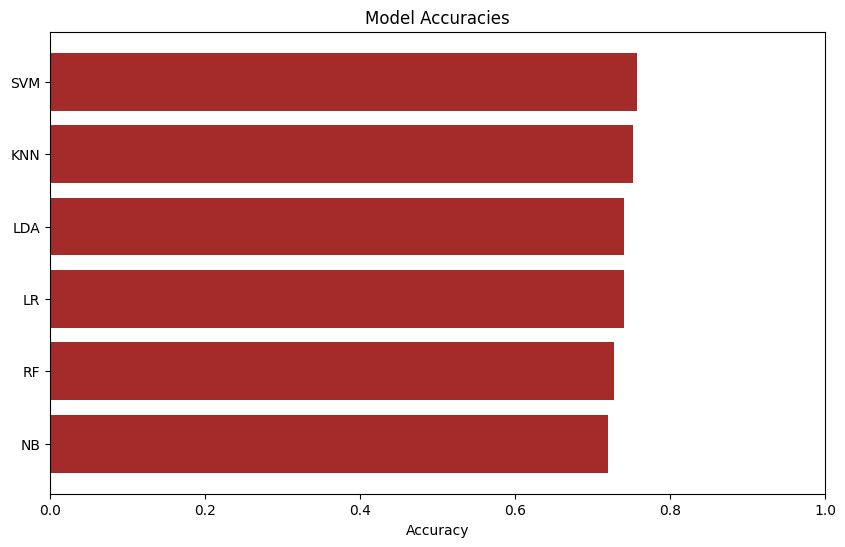

In [ ]:
import matplotlib.pyplot as plt

accuracies = [result[0] for result in results]
model_names = ["RF", "SVM", "KNN", "LR", "NB", "LDA"]
model_accuracy = {model: accuracy for model, accuracy in zip(model_names, accuracies)}
model_accuracy = dict(sorted(model_accuracy.items(), key=lambda item: item[1], reverse=False))

plt.figure(figsize=(10, 6))
plt.barh(model_accuracy.keys(), model_accuracy.values(), color="brown")
plt.ylabel("")
plt.xlabel("Accuracy")
plt.title("Model Accuracies")
plt.xlim(0,1)
plt.show()

In [ ]:
lr_model = LogisticRegression(penalty="l1", solver="liblinear", C=0.5)
crash_data_df = pd.read_csv("crash_data.csv")
crash_data_df = crash_data_df.drop(columns=["TractID", "num_crashes"])
crash_data = crash_data_df[['population_density', 'bus_stops', 'daily_traffic', 'speed_bumps', 'weighted_speed_limit', 'pct_tl_crosswalk']]

scaler = StandardScaler()
scaled_features = pd.DataFrame(scaler.fit_transform(crash_data), columns=crash_data.columns)
lr_model.fit(scaled_features, crash_data_df["high_crash_rate"])

LogisticRegression(C=0.5, penalty='l1', solver='liblinear')

In [ ]:
scaled_features = sm.add_constant(scaled_features)
model = sm.Logit(crash_data_df["high_crash_rate"], scaled_features)
model = model.fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.513107
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        high_crash_rate   No. Observations:                  239
Model:                          Logit   Df Residuals:                      232
Method:                           MLE   Df Model:                            6
Date:                Tue, 29 Apr 2025   Pseudo R-squ.:                  0.2506
Time:                        16:13:12   Log-Likelihood:                -122.63
converged:                       True   LL-Null:                       -163.65
Covariance Type:            nonrobust   LLR p-value:                 1.362e-15
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.5104      0.170      3.005      0.003       0.177       0.843

In [ ]:
import statsmodels.api as sm

full_crime_df = full_crime_df[full_crime_df.index!="Census Tract 9803"]

full_crime_df["gini_poverty"] = full_crime_df["gini_index"] * full_crime_df["pct_poverty"]

full_crime_df_train = full_crime_df.drop(columns=[
    "violent_crimes", "high_crime", "geometry",
    "Elementary", "High", "Middle", "Private",
    "Religious", "high_crime", "post_offices", "grocery_stores",
    "libraries", "gini_index", "pct_poverty"
    ]
)



                            OLS Regression Results                            
Dep. Variable:         violent_crimes   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     18.81
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           5.93e-25
Time:                        20:33:02   Log-Likelihood:                -243.81
No. Observations:                 238   AIC:                             509.6
Df Residuals:                     227   BIC:                             547.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  5.0857      0

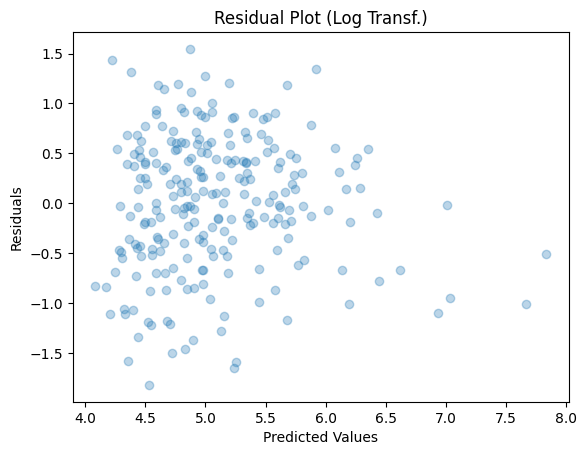

In [ ]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

scaler = StandardScaler()
scaled_features = pd.DataFrame(scaler.fit_transform(full_crime_df_train),
                               columns=full_crime_df_train.columns,
                               index=full_crime_df_train.index)
scaled_features = sm.add_constant(scaled_features)
model = sm.OLS(np.log(full_crime_df["violent_crimes"]), scaled_features)
model = model.fit()
print(model.summary())

y_preds = model.predict(scaled_features)
residuals = np.log(full_crime_df["violent_crimes"]) - y_preds
plt.scatter(y_preds, residuals, alpha=0.3)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Log Transf.)")
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assume X is your feature matrix
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(scaled_features.values, i) for i in range(scaled_features.shape[1])]
vif["feature"] = scaled_features.columns
print(vif)

         VIF             feature
0   1.000000               const
1   1.190976          Population
2   1.157789         pct_poverty
3   1.135447  population_density
4   1.289777        TotalSchools
5   1.674057     worship_centers
6   1.182727          gini_index
7   1.430434               parks
8   1.625216     financial_insts
9   1.285816      med_facilities
10  1.682337            daycares
11  1.434525    shopping_centers


                            OLS Regression Results                            
Dep. Variable:         violent_crimes   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.472
Method:                 Least Squares   F-statistic:                     4.934
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           2.29e-16
Time:                        00:17:18   Log-Likelihood:                -209.47
No. Observations:                 239   AIC:                             528.9
Df Residuals:                     184   BIC:                             720.1
Df Model:                          54                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

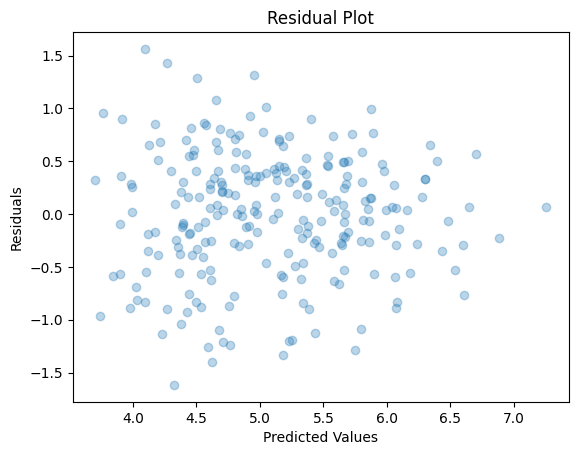

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly_features.fit_transform(full_crime_df_train)
feature_names = poly_features.get_feature_names_out(full_crime_df_train.columns)
poly_x = pd.DataFrame(X_poly, columns=feature_names, index=full_crime_df_train.index)

scaler = StandardScaler()

scaled_poly_features = pd.DataFrame(scaler.fit_transform(poly_x),
                                    columns=poly_x.columns,
                                    index=poly_x.index)

scaled_poly_features = sm.add_constant(scaled_poly_features)

model = sm.OLS(np.log(full_crime_df["violent_crimes"]), scaled_poly_features)
model = model.fit()
print(model.summary())

y_preds = model.predict(scaled_poly_features)
residuals = np.log(full_crime_df["violent_crimes"]) - y_preds
plt.scatter(y_preds, residuals, alpha=0.3)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

                 Generalized Linear Model Regression Results                  
Dep. Variable:         violent_crimes   No. Observations:                  239
Model:                            GLM   Df Residuals:                      230
Model Family:        NegativeBinomial   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1843.2
Date:                Tue, 29 Apr 2025   Deviance:                       1342.0
Time:                        01:30:22   Pearson chi2:                 2.58e+03
No. Iterations:                    16   Pseudo R-squ. (CS):             0.9453
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -2.7649      0.021  

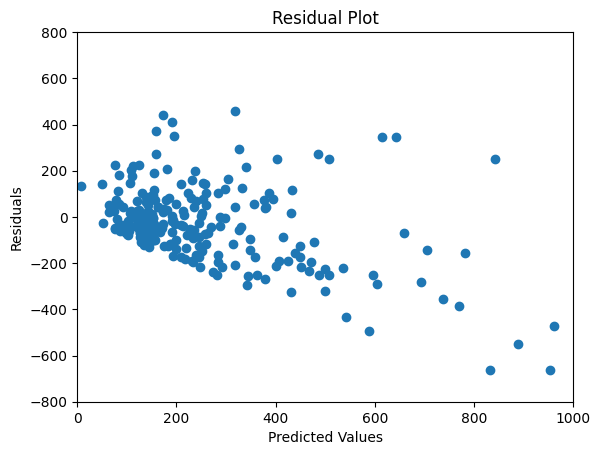

Cross-validated RMSE: 221.60871417044783


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

X = scaled_features.drop(columns=["Population"])
y = full_crime_df["violent_crimes"]

nb_model = sm.GLM(
    y,
    X,
    family=sm.families.NegativeBinomial(alpha=0.1),
    exposure=full_crime_df_train["Population"]
)
nb_results = nb_model.fit()
print(nb_results.summary())

y_preds = nb_results.predict(
    scaled_features.drop(columns=["Population"]),
    exposure = full_crime_df_train["Population"]
)
residuals = full_crime_df["violent_crimes"] - y_preds
plt.scatter(y_preds, residuals, alpha=1)
plt.xlabel("Predicted Values")
plt.xlim(0, 1000)
plt.ylim(-800, 800)
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

X_np = X.values
y_np = y.values
exposure_np = full_crime_df_train["Population"].values
kf = KFold(n_splits=8, shuffle=True, random_state=42)
rmse_list = []
for train_index, test_index in kf.split(X_np):
    X_train, X_test = X_np[train_index], X_np[test_index]
    y_train, y_test = y_np[train_index], y_np[test_index]
    exposure_train = exposure_np[train_index]
    exposure_test = exposure_np[test_index]

    model = sm.GLM(
        y,
        X,
        family=sm.families.NegativeBinomial(alpha=0.1),
        exposure=full_crime_df_train["Population"]
    )
    results = model.fit()
    y_pred = results.predict(X_test, exposure=exposure_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_list.append(rmse)
cv_rmse = np.mean(rmse_list)
print(f"Cross-validated RMSE: {cv_rmse}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:         violent_crimes   No. Observations:                  239
Model:                            GLM   Df Residuals:                      229
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10123.
Date:                Tue, 29 Apr 2025   Deviance:                       18590.
Time:                        00:57:32   Pearson chi2:                 1.95e+04
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                5.3190      0.005  

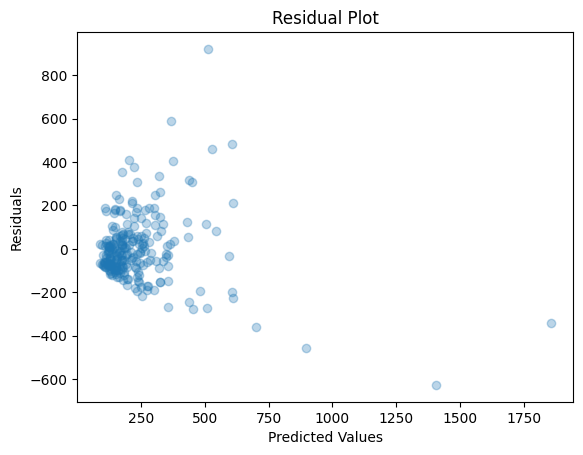

In [ ]:
poisson_model = sm.GLM(
    full_crime_df["violent_crimes"],
    scaled_features,
    family=sm.families.Poisson()
)
poisson_results = poisson_model.fit()
print(poisson_results.summary())

y_preds = poisson_results.predict(scaled_features)
residuals = full_crime_df["violent_crimes"] - y_preds
plt.scatter(y_preds, residuals, alpha=0.3)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
from sklearn.metrics import make_scorer

model = sklearn_sm(
    sm.OLS,
    MS(scaled_features.columns),
)

cv_results = cross_validate(
    model,
    scaled_features,
    full_crime_df["violent_crimes"],
    cv=8,
    scoring="neg_root_mean_squared_error"
)
cv_err = np.mean(cv_results['test_score'])
cv_err

-164.10318640088462